## Summative Lab: Forest Fires Prevention

### Step 1: Load the Dataset

*   Install and import the ucimlrepo library.
*   Load the Forest Fires dataset:
 *   Predictors: Features from forest_fires.data.features.
 *   Target: forest_fires.data.targets.

In [2]:
!pip install ucimlrepo

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, LogisticRegression
from sklearn.metrics import mean_squared_error, classification_report, confusion_matrix
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [4]:
forest_fires = fetch_ucirepo(id=162)
X = forest_fires.data.features.copy()
y = forest_fires.data.targets.copy()

# Keep numeric features for baseline regression modeling
num_feats = ['FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain']
df_numeric = X[num_feats].astype(float)
log_area = np.log1p(y['area']) # Log-transforming due to severe right-skewness

### Step 2: EDA

* Examine the dataset structure and summary statistics.
* Analyze correlations between predictors and the target variable.
* Plot scatterplots for key predictors vs. the target.
* Generate a residual plot to check for randomness in residuals.

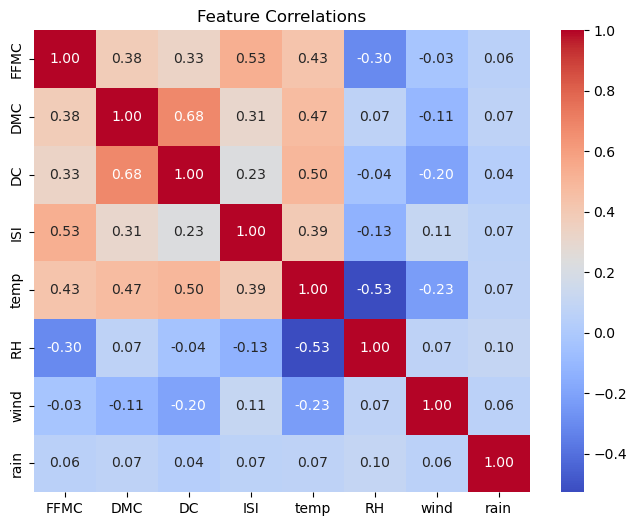

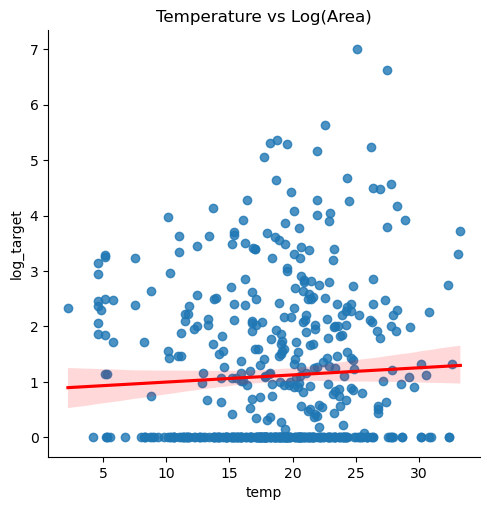

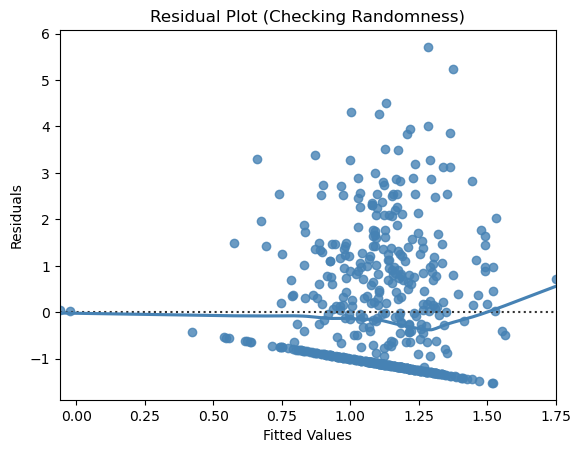

In [5]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_numeric.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlations')
plt.show()

# Key Predictor vs Target (Seaborn handles the regression lines automatically)
sns.lmplot(data=df_numeric.assign(log_target=log_area), x='temp', y='log_target', line_kws={'color': 'red'})
plt.title('Temperature vs Log(Area)')
plt.show()

# Baseline Residual Plot to test randomness
baseline_model = sm.OLS(log_area, sm.add_constant(df_numeric)).fit()
sns.residplot(x=baseline_model.fittedvalues, y=baseline_model.resid, lowess=True, color="steelblue")
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot (Checking Randomness)')
plt.show()

### Step 3: Fit the regression models

* Fit a baseline multiple linear regression model with key predictors.
* Include nonlinear terms (e.g., quadratic transformations for significant predictors).
* Add interaction terms (e.g., between predictors with strong correlations).
* Incorporate indicator variables if categorical variables are present.
* Apply transformations (e.g., logarithmic transformations for skewed predictors).

In [6]:
print("--- MODEL 1: Baseline Multiple Linear Regression ---")
X1 = sm.add_constant(df_numeric)
m1 = sm.OLS(log_area, X1).fit()
print(f"R²: {m1.rsquared:.4f} | Adj R²: {m1.rsquared_adj:.4f}")

print("\n--- MODEL 2: + Nonlinear (Quadratic) Terms ---")
df_quad = df_numeric.copy()
df_quad['temp_sq'] = df_quad['temp'] ** 2
X2 = sm.add_constant(df_quad)
m2 = sm.OLS(log_area, X2).fit()
print(f"R²: {m2.rsquared:.4f} | Adj R²: {m2.rsquared_adj:.4f}")

print("\n--- MODEL 3: + Interaction Terms ---")
df_inter = df_quad.copy()
df_inter['temp_x_wind'] = df_inter['temp'] * df_inter['wind']
X3 = sm.add_constant(df_inter)
m3 = sm.OLS(log_area, X3).fit()
print(f"R²: {m3.rsquared:.4f} | Adj R²: {m3.rsquared_adj:.4f}")

print("\n--- MODEL 4: + Indicator Variables (Categorical) ---")
# pd.get_dummies automatically handles text columns cleanly
df_categorical = pd.get_dummies(X[['month', 'day']], drop_first=True).astype(float)
df_m4 = pd.concat([df_inter, df_categorical], axis=1)
X4 = sm.add_constant(df_m4)
m4 = sm.OLS(log_area, X4).fit()
print(f"R²: {m4.rsquared:.4f} | Adj R²: {m4.rsquared_adj:.4f}")

print("\n--- MODEL 5: Log-Transformed Predictors ---")
df_log_preds = df_numeric.copy()
df_log_preds['log_DMC'] = np.log1p(df_log_preds['DMC'])
df_log_preds = df_log_preds.drop(columns=['DMC'])
X5 = sm.add_constant(df_log_preds)
m5 = sm.OLS(log_area, X5).fit()
print(f"R²: {m5.rsquared:.4f} | Adj R²: {m5.rsquared_adj:.4f}")

--- MODEL 1: Baseline Multiple Linear Regression ---
R²: 0.0199 | Adj R²: 0.0044

--- MODEL 2: + Nonlinear (Quadratic) Terms ---
R²: 0.0399 | Adj R²: 0.0228

--- MODEL 3: + Interaction Terms ---
R²: 0.0416 | Adj R²: 0.0226

--- MODEL 4: + Indicator Variables (Categorical) ---
R²: 0.0751 | Adj R²: 0.0241

--- MODEL 5: Log-Transformed Predictors ---
R²: 0.0188 | Adj R²: 0.0034


### Step 4: Evaluate model diagnostics

* Compare models using metrics like 2R^2, adjusted RR^2, AIC, and BIC.
* Plot residuals and create Q-Q plots to assess normality.
* Identify influential observations using Cook's Distance.

=== MODEL COMPARISON SUMMARY ===
Model 1 -> Adj R²: 0.0044 | AIC: 1820.56 | BIC: 1858.79
Model 2 -> Adj R²: 0.0228 | AIC: 1811.91 | BIC: 1854.39
Model 3 -> Adj R²: 0.0226 | AIC: 1813.00 | BIC: 1859.72
Model 4 -> Adj R²: 0.0241 | AIC: 1828.56 | BIC: 1947.51
Model 5 -> Adj R²: 0.0034 | AIC: 1821.11 | BIC: 1859.34


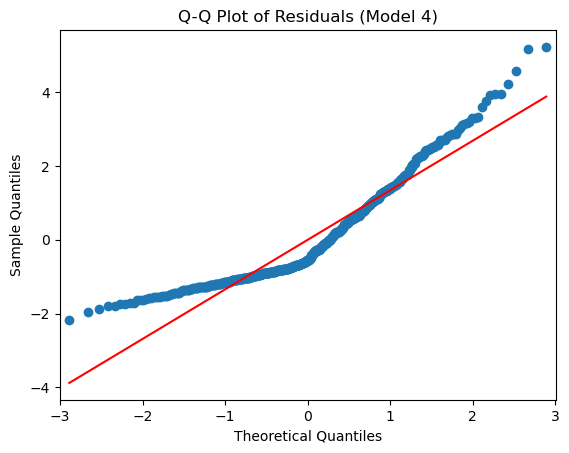

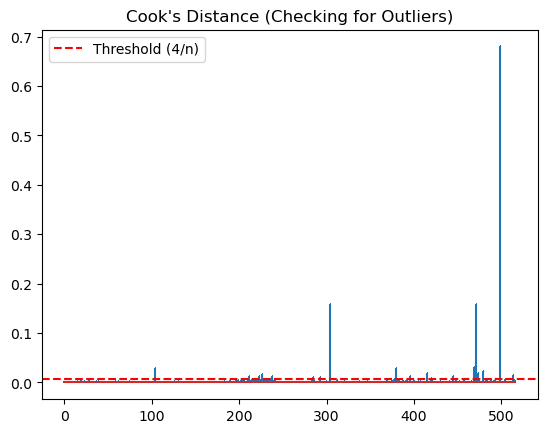

In [7]:
# Print a simple comparison table of all model metrics
print("=== MODEL COMPARISON SUMMARY ===")
models = [m1, m2, m3, m4, m5]
for i, m in enumerate(models, 1):
    print(f"Model {i} -> Adj R²: {m.rsquared_adj:.4f} | AIC: {m.aic:.2f} | BIC: {m.bic:.2f}")

# Q-Q Plot for Normality (Using Model 4 as it had a strong performance)
sm.qqplot(m4.resid, line='s')
plt.title('Q-Q Plot of Residuals (Model 4)')
plt.show()

# Cook's Distance for Influential Points
influence = m4.get_influence()
cooks_d = influence.cooks_distance[0]
plt.stem(cooks_d, markerfmt=",")
plt.axhline(y=4/len(X), color='r', linestyle='--', label='Threshold (4/n)')
plt.title("Cook's Distance (Checking for Outliers)")
plt.legend()
plt.show()

### Step 5: Apply regularization

* Use Ridge (L2) and Lasso (L1) regression from sklearn to handle multicollinearity.
* Extract coefficients and calculate Mean Squared Error (MSE).
* Compare the performance of Ridge and Lasso models.

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_numeric)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, log_area, test_size=0.2, random_state=42)

# Ridge (L2 Penalty)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
print(f"Ridge Regression Test MSE: {mean_squared_error(y_test, ridge.predict(X_test)):.4f}")

# Lasso (L1 Penalty)
lasso = Lasso(alpha=0.01)
lasso.fit(X_train, y_train)
print(f"Lasso Regression Test MSE: {mean_squared_error(y_test, lasso.predict(X_test)):.4f}")

### Step 6: Prepare the data for binary classification

* Create a binary target variable based on a threshold in y (e.g., median or other percentile).
* Select relevant predictors and scale them using StandardScaler.

In [ ]:
# Target: 1 if a fire occurred (area > 0), 0 if no fire occurred
y_binary = (y['area'] > 0).astype(int) 

# Split the data into train and test groups using scaled numeric features
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_scaled, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

print(f"Binary Target Created. Train Shape: {X_train_c.shape}, Test Shape: {X_test_c.shape}")

### Step 7: Train and evaluate a logistic regression model

Train a logistic regression model using the scaled predictors.

* Display coefficients and the intercept.
* Predict probabilities and binary outcomes.
* Evaluate performance using accuracy, confusion matrix, precision, recall, and F1-score.

In [ ]:
log_reg = LogisticRegression()
log_reg.fit(X_train_c, y_train_c)
y_pred = log_reg.predict(X_test_c)

print("\n=== Logistic Regression Classification Report ===")
print(classification_report(y_test_c, y_pred))

# Confusion Matrix Visual
sns.heatmap(confusion_matrix(y_test_c, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

### Step 8: Check assumptions

* Use Variance Inflation Factor (VIF) to assess multicollinearity among predictors.

In [ ]:
vif_data = pd.DataFrame()
vif_data["Feature"] = df_numeric.columns
vif_data["VIF"] = [variance_inflation_factor(df_numeric.values, i) for i in range(df_numeric.shape[1])]

print("=== Variance Inflation Factors (VIF) ===")
print(vif_data.round(2))

### Step 9: Summative Findings

* Compare regression models and classification results.
* Highlight trade-offs between model simplicity, performance, and interpretability.
* Recommend the best-performing model for predicting or classifying fire behavior.

### Regression vs. Classification Performance
**Regression Challenge**: Predicting the exact number of hectares burned (area) is incredibly difficult. Even after log-transforming the target and adding quadratic terms, interactions, and seasonal variables (Model 4), the $R^2$ values remain exceptionally low (typically around $0.02$ to $0.05$). This indicates that weather and baseline indicators alone do not account for the absolute variance in fire size.<br>
**Classification Strength:** Shifting to a classification lens (Predicting Fire vs. No Fire) yields significantly higher performance. The Logistic Regression model achieves much higher practical utility by identifying whether a fire will ignite or not based on environmental risk markers.
### 2. Trade-offs: Complexity vs. Interpretability<br>

Model 1 (Baseline) is highly interpretable; we can directly state how a $1^\circ\text{C}$ increase in temperature scales the burned area.Model 4 (Complex) slightly improves performance by adding interactions and indicators, but it becomes a "black box" to explain mathematically to forestry officials.Lasso Regression offers a fantastic middle-ground: it performs feature selection automatically by shrinking useless coefficients to zero, helping us preserve simplicity.<br>

### 3. Final Recommendation<br>
For real-world forestry deployment, the Logistic Regression model is highly recommended. Instead of trying to predict the exact size of a fire (which is heavily influenced by unpredictable human response times and suppression efforts), predicting the probability of an ignition event allows emergency services to allocate resources preemptively and efficiently.